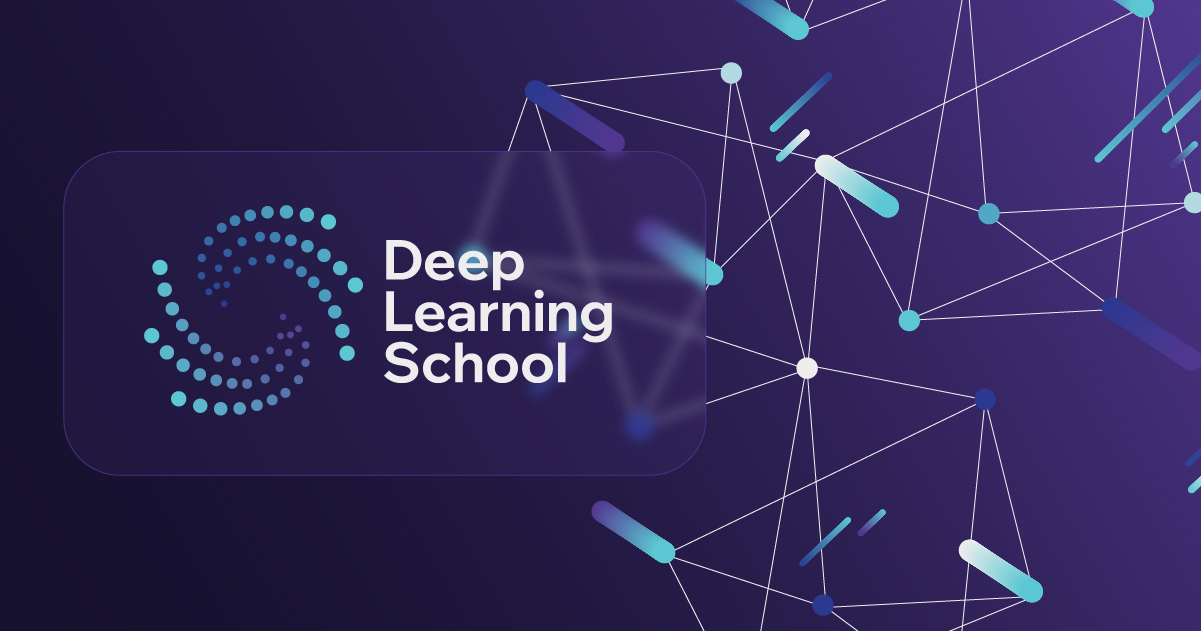


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 990 картнок, для которых вам будет необходимо предсказать класс.

### Установка зависимостей

In [2]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [3]:
# from google.colab import drive
# drive.mount('/content/gdrive/')

In [4]:
# !unzip -q /content/gdrive/MyDrive/journey-springfield.zip

In [5]:
# !ls train

In [6]:
# !ls data

In [7]:
# !ls data/train

In [8]:
!nvidia-smi
import torch
# torch.cuda.is_available()

Sun Nov 16 16:08:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 571.96                 Driver Version: 571.96         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti   WDDM  |   00000000:3B:00.0  On |                  N/A |
|  0%   42C    P2             42W /  285W |    1783MiB /  12282MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import torch
import torchvision.io as io
import torchvision.transforms.functional as F

import pandas as pd

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


In [10]:
# это пакет для проверки версий других пакетов
import pkg_resources

In [11]:
!python --version

Python 3.11.0


In [12]:
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ pkg_resources.get_distribution(b).version)

torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121
tqdm version: 4.67.1
matplotlib version: 3.10.7
seaborn version: 0.13.2
Pillow version: 12.0.0


#### Версии питона и библиотек, на которых работал эталонный ноутбук:

Python 3.11.11

torch version: 2.5.1+cu124

torchvision version: 0.20.1+cu124

tqdm version: 4.67.1

matplotlib version: 3.10.0

seaborn version: 0.13.2

Pillow version: 11.1.0


In [13]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']
# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = 224
# работаем на видеокарте
DEVICE = torch.device("cuda")

NUM_WORKERS=0

Полезная статья, которой мы вдохновились при создании класса `SimpsonsDataset`:

https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/

Ниже мы исспользуем враппер над датасетом для удобной работы. Вам стоит понимать, что происходит с LabelEncoder и  с torch.Transformation.

`ToTensor` конвертирует  `PIL Image` с параметрами в диапазоне $[0, 255]$ (как все пиксели) в `FloatTensor` размера ($C \times H \times W$) $[0,1]$ , затем производится масштабирование:
$\text{input} = \frac{\text{input} - \mu}{\text{standard deviation}} $, <br>       константы - средние и дисперсии по каналам на основе ImageNet


Стоит также отметить, что мы переопределяем метод __getitem__ для удобства работы с данной структурой данных.
 Также используется LabelEncoder для преобразования строковых меток классов в id и обратно. В описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следуем привести их к одному размеру (это делает метод  _prepare_sample).

In [14]:
class SimpsonsDataset(Dataset):
    """
    Датасет с картинками, который паралельно подгружает их из папок
    производит скалирование и превращение в торчевые тензоры
    """
    def __init__(self, files, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode

        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.len_ = len(self.files)

        self.label_encoder = LabelEncoder()

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder.fit(self.labels)

            with open('label_encoder.pkl', 'wb') as le_dump_file:
                  pickle.dump(self.label_encoder, le_dump_file)

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file)
        image.load()
        return image

    def __getitem__(self, index):
        # для преобразования изображений в тензоры PyTorch и нормализации входа
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        x = self.load_sample(self.files[index])
        x = self._prepare_sample(x)
        x = np.array(x / 255, dtype='float32')
        x = transform(x)
        if self.mode == 'test':
            return x
        else:
            label = self.labels[index]
            label_id = self.label_encoder.transform([label])
            y = label_id.item()
            return x, y

    def _prepare_sample(self, image):
        image = image.resize((RESCALE_SIZE, RESCALE_SIZE))
        return np.array(image)

In [15]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [16]:
#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('./data/train/')
TEST_DIR = Path('./data/testset')

In [17]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [18]:
from sklearn.model_selection import train_test_split

train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [19]:
val_dataset = SimpsonsDataset(val_files, mode='val')

In [20]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам.

Давайте посмотрим на наших героев внутри датасета.

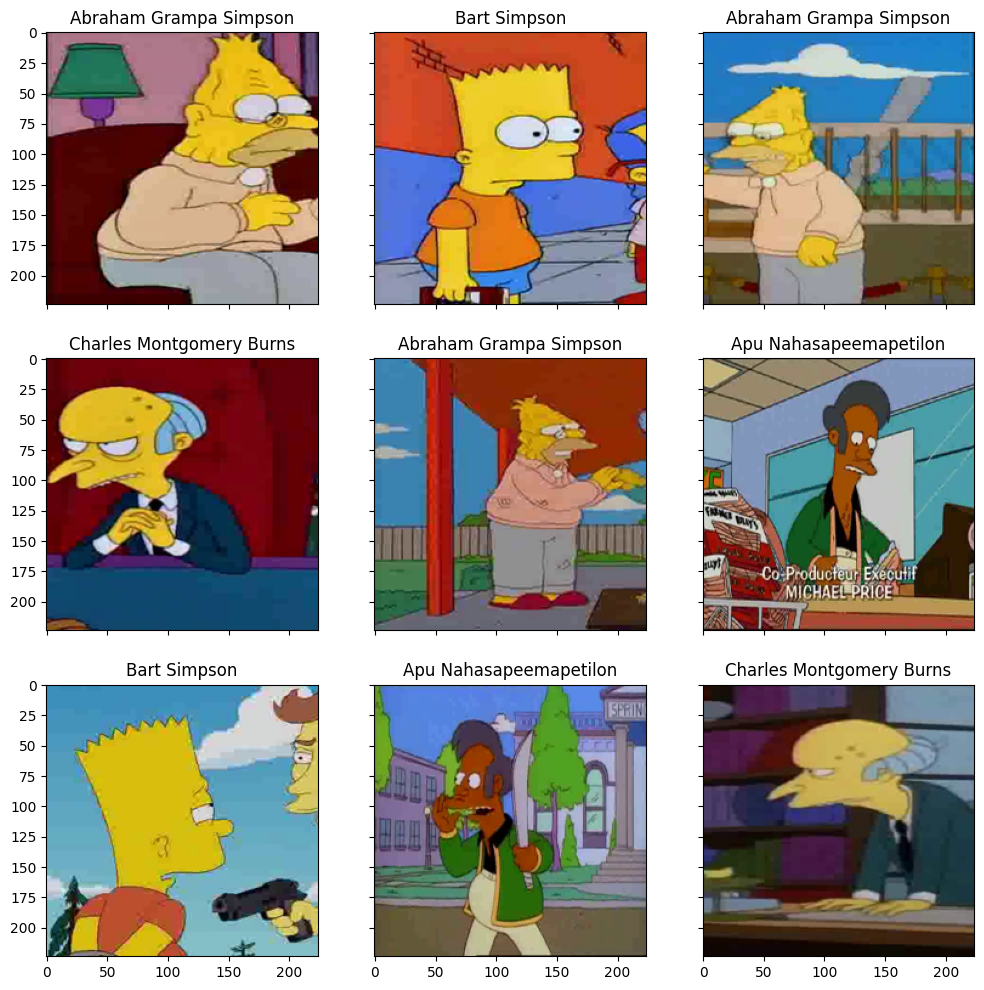

In [21]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

Можете добавить ваши любимые сцены и классифицировать их. (веселые результаты можно кидать в чат)

### Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

<!-- Здесь вам предлагается дописать сверточную сеть глубины 4/5.  -->

*Описание слоев*:



1. размерность входа: $3\times 224 \times 224$
2.размерности после слоя:  $8 \times 111 \times 111$
3. $16 \times 54 \times 54$
4. $32 \times 26 \times 26$
5. $64 \times 12 \times 12$
6. выход: $96 \times 5 \times 5$

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [22]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

#### Функция обучения:

In [23]:
def fit_epoch(model, train_loader, criterion, optimizer):
    """
    Функция обучает модель на одной эпохе, используя предоставленный dataloader.

    Эта функция проходит по всем данным в `train_loader`, выполняет шаг моделью (forward),
    вычисляет лосс, выполняет обратное распространение с помощью заданного
    оптимизатора и обновляет веса модели.
    В конце эпохи возвращаются средний лосс и
    точность на обучающем наборе данных.

    Параметры:
    ----------
    model : nn.Module
        Модель, которую необходимо обучить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    train_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных и
        соответствующих меток. Должен возвращать кортежи (inputs, labels).

    criterion : nn.Module
        Функция потерь, используемая для вычисления ошибки между
        предсказаниями модели и истинными метками.

    optimizer : torch.optim.Optimizer
        Оптимизатор, используемый для обновления весов модели на основе
        градиентов, вычисленных в процессе обучения.

    Функция возвращает:
    ----------
    tuple
        Кортеж, содержащий средний лосс (train_loss) и точность (train_acc)
        на обучающем наборе данных за текущую эпоху.
    """

    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

#### Функция валидации:

In [24]:
def eval_epoch(model, val_loader, criterion):
    """
    Функция оценивает работу модели на валидационном наборе данных за одну эпоху.

    Эта функция проходит по всем данным в `val_loader`, выполняет прямое
    распространение, вычисляет лосс и точность модели. В конце эпохи
    возвращаются средний лосс и точность на валидационном наборе данных.

    Параметры:
    ----------
    model : nn.Module
        Модель, которую необходимо оценить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    val_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных и
        соответствующих меток для валидации. Должен возвращать кортежи
        (inputs, labels).

    criterion : nn.Module
        Функция потерь, используемая для вычисления ошибки между
        предсказаниями модели и истинными метками.

    Функция возвращает:
    ----------
    tuple
        Кортеж, содержащий среднюю потерю (val_loss) и точность (val_acc)
        на валидационном наборе данных за текущую эпоху.
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.double() / processed_size
    return val_loss, val_acc

#### Полный цикл обучения

In [25]:
def train(train_dataset, val_dataset, model, epochs, batch_size, optimizer=None):
    """
    Функция обучает модель на обучающем наборе данных и оценивает ее на валидационном наборе данных.

    Эта функция создает загрузчики данных для обучающего и валидационного наборов,
    а затем выполняет обучение модели в течение заданного количества эпох.
    В конце каждой эпохи выводятся значения потерь и точности для обучающего и
    валидационного наборов. История обучения сохраняется и возвращается.

    Параметры:
    ----------
    train_dataset
        Обучающие данные.

    val_dataset
        Валидационные данные.

    model : nn.Module
        Модель, которую необходимо обучить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    epochs : int
        Количество эпох для обучения модели.

    batch_size : int
        Размер батча, используемый для загрузки данных.

    Возвращает:
    ----------
    list
        Список, содержащий кортежи (train_loss, train_acc, val_loss, val_acc)
        для каждой эпохи, где:
        - train_loss: средняя потеря на обучающем наборе.
        - train_acc: точность на обучающем наборе.
        - val_loss: средняя потеря на валидационном наборе.
        - val_acc: точность на валидационном наборе.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        if optimizer is None:
            optimizer = torch.optim.Adam(model.parameters())
        else:
            # К готовому коду из исходного ноутбука
            # добавляем возможность подменить оптимизатор
            pass 
        
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))

    return history

#### Применение модели к данным

In [26]:
def predict(model, test_loader):
    """
    Функция выполняет предсказание классов для тестового набора данных с использованием обученной модели.

    Эта функция принимает модель и загрузчик тестовых данных, применяет модель к
    изображениям и возвращает вероятности предсказанных классов.

    Параметры:
    ----------
    model : nn.Module
        Обученная модель, которая будет использоваться для предсказания.
        Должна быть экземпляром класса PyTorch `nn.Module`.

    test_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных для тестирования.
        Должен возвращать тензоры входных данных.

    Возвращает:
    ----------
    numpy.ndarray
        Массив вероятностей предсказанных классов для каждого примера в тестовом наборе.
        Размерность массива будет (N, C), где N - количество примеров, а C - количество классов.
    """

    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [27]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify: {} classes".format(n_classes))
print(simple_cnn)

we will classify: 42 classes
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv5): Sequential(
    (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=2400,

Запустим обучение сети.

In [28]:
if val_dataset is None:
    val_dataset = SimpsonsDataset(val_files, mode='val')

train_dataset = SimpsonsDataset(train_files, mode='train')

In [29]:
optimizer = torch.optim.Adam(simple_cnn.parameters())
# history = train(train_dataset, val_dataset, model=simple_cnn, epochs=2, batch_size=64)

Построим кривые обучения

In [30]:
loss, acc, val_loss, val_acc = zip(*history)

NameError: name 'history' is not defined

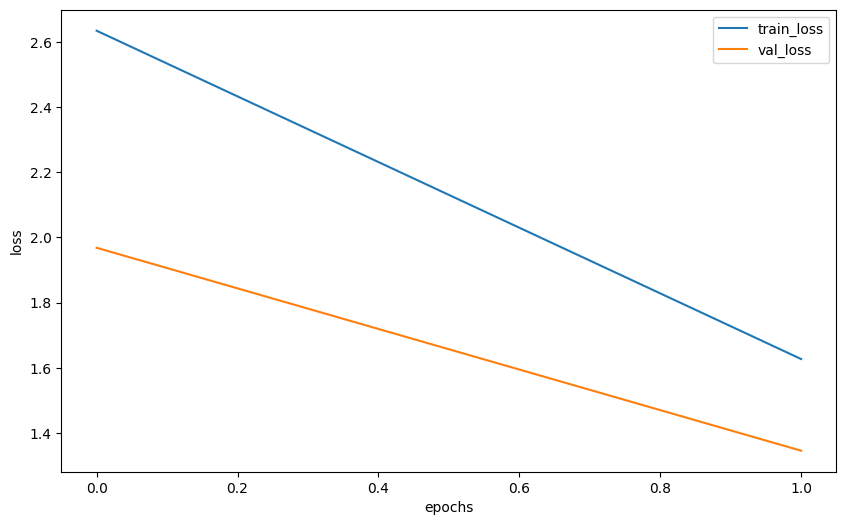

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Хорошо бы понять, как сделать сабмит.
У нас есть сеть и методы eval у нее, которые позволяют перевести сеть в режим предсказания. Стоит понимать, что у нашей модели на последнем слое стоит `softmax`, которые позволяет получить вектор вероятностей  того, что объект относится к тому или иному классу. Давайте воспользуемся этим.

In [ ]:
def predict_one_sample(model, inputs, device=DEVICE):
    """Предсказание, для одной картинки"""
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).cpu()
        probs = torch.nn.functional.softmax(logit, dim=-1).numpy()
    return probs

In [ ]:
random_characters = int(np.random.uniform(0,1000))
ex_img, true_label = val_dataset[random_characters]
probs_im = predict_one_sample(simple_cnn, ex_img.unsqueeze(0))

In [ ]:
idxs = list(map(int, np.random.uniform(0,1000, 20)))
imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]

probs_ims = predict(simple_cnn, imgs)

In [39]:
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))

In [ ]:
y_pred = np.argmax(probs_ims,-1)

actual_labels = [val_dataset[id][1] for id in idxs]

preds_class = [label_encoder.classes_[i] for i in y_pred]

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Вычислим целевую метрику на валидационной выборке.

In [37]:
from sklearn.metrics import f1_score
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)

NameError: name 'actual_labels' is not defined

Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах. Можете исспользовать это, чтобы отлаживать правильность вывода.

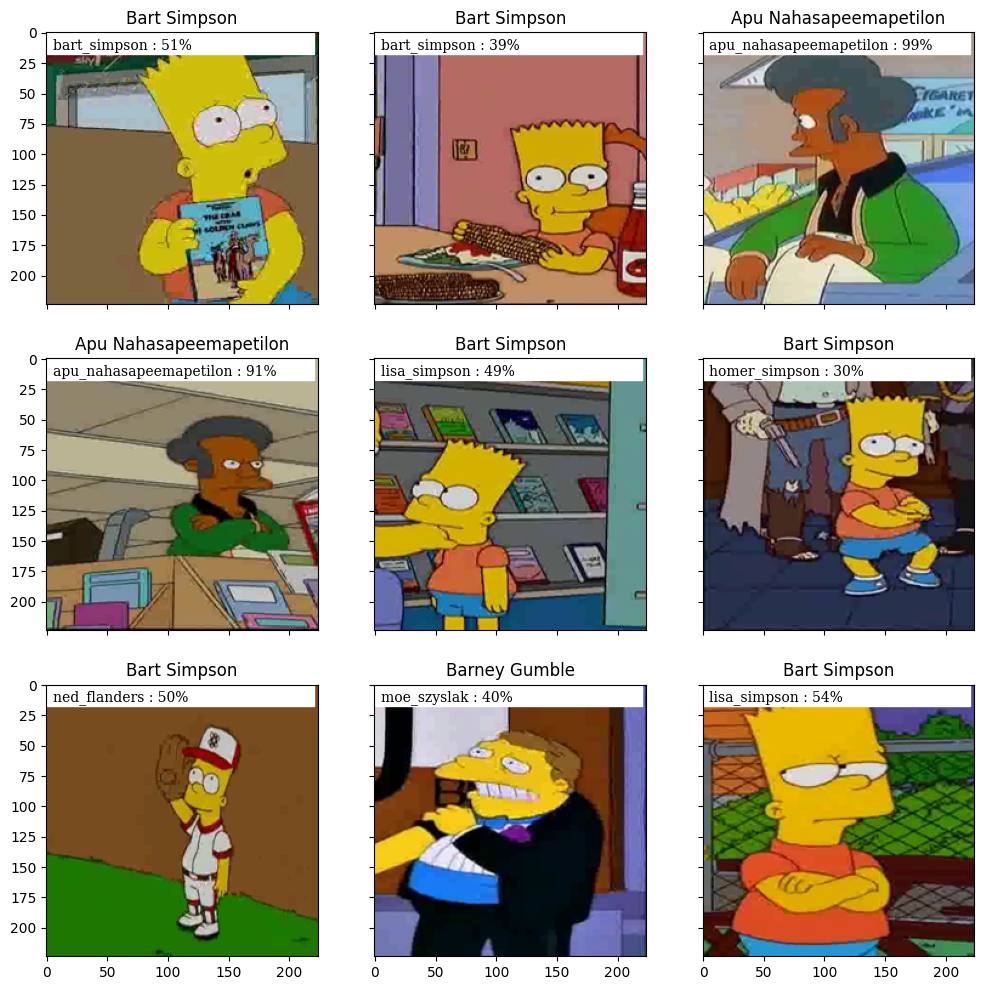

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))



    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 0),220,17,color='white'))
    font0 = FontProperties()
    font = font0.copy()
    font.set_family("serif")
    prob_pred = predict_one_sample(simple_cnn, im_val.unsqueeze(0))
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(5, 4, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=10, color='black')

Попробуйте найти те классы, которые сеть не смогла расспознать. Изучите данную проблему, это понадобится в дальнейшем.

### Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

In [ ]:
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)
probs = predict(simple_cnn, test_loader)


preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
test_filenames = [path.name for path in test_dataset.files]


## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся скор нас явно не устраивает. Надо с этим что-то сделать.

Несколько срочныйх улучшейни для нашей сети, которые наверняка пришли Вам в голову:
1. Работа с датасетом:
* проверка (EDA) и предобработка;
* дополнение, выравниванике кол-ва картинок в классах - изменять можно как сами картинки, формируя новый датасет, или в класссе SimpsonsDataset;
* с помощью [аугментации](https://habr.com/ru/companies/smartengines/articles/264677/) или [без](https://www.geeksforgeeks.org/python-data-augmentation/);

2. Рабта с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных слоёв;
* кто же так строит нейронные сети? А где пулинги и батч нормы? Надо добавлять!

3. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

4. Файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

5. Стоит подумать об ансамблях


Надеюсь, что у Вас получится!

![alt text](https://pbs.twimg.com/profile_images/798904974986113024/adcQiVdV.jpg)


---
# Начало решения 

Predict + Submit удобно выделить в функцию

In [31]:
def predict_and_submit(model, submit_name):
    probs = predict(model, test_loader)
    preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
    submit = pd.DataFrame({'Id': test_filenames, 'Expected': preds})
    submit.to_csv(f'{submit_name}.csv', index=False)

Аналогично и с графиком лосса по эпохам

In [32]:
def plot_epoch_loss(history):
    loss, acc, val_loss, val_acc = zip(*history)

    plt.figure(figsize=(7, 4))
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.legend(loc='best')
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.ylim(0, 3.5) 
    plt.show()

И для расчета F1-оценки

In [33]:
def evaluate_f1_score(model):
    idxs = list(map(int, np.random.uniform(0,1000, 800)))
    imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]
    probs_ims = predict(model, imgs)
    y_pred = np.argmax(probs_ims,-1)
    actual_labels = [val_dataset[id][1] for id in idxs]
    return f1_score(actual_labels, y_pred, average='micro')

# Борис Треухов посоветовал

> ахтунг ахтунг, вот ща в правильный поток написал )
> 
> короче, очень сильно ускоряется на локальной видюхе если через торчвижн сразу загружать в ГПУ без всяких Pillow

> import torchvision.io as io
> def load_image(self, file):
>         data = io.read_file(str(file))
>         return io.decode_jpeg(data, device='cuda')

> ну мб кому то подойдет больше CPU вариант, а потом (tensor_transformed.to('cuda', non_blocking=True)) если аугментаций много

> еще у меня последняя версия libjpeg turbo из репы собрана, не знаю влияет или нет но ускорилось 2.5x

> P.S. еще io.decode_jpeg список(list) CPU тензоров принимает(по крайней мере в последней версии торчвижн) - можно засосать весь датасет при желании(вроде 12гб) либо сделать коллацию батча попробовать чтобы хотя бы батч одним.. батчем сразу распаковывать из JPG прямо на GPU - nb сами JPEG всегда приходят как CPU тензоры, но распаковываются как GPU тензоры если device='cuda' указать


Я как раз тренирую локально на 4070 ti, время не прочь сэкономить, так что ниже - реализация даталоадера по советам выше.

In [34]:
class SimpsonsDatasetGpu(Dataset):
    def __init__(self, files, mode):
        super().__init__()
        self.files = sorted(files)
        self.mode = mode
        self.len_ = len(self.files)
        self.rescale = (RESCALE_SIZE, RESCALE_SIZE)
        self.mean = [0.485, 0.456, 0.406]
        self.std  = [0.229, 0.224, 0.225]

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(self.labels)
        else:
            self.labels = None
            self.label_encoder = None

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        data = io.read_file(str(file))                 # CPU bytes
        img = io.decode_jpeg(data, device='cuda')     # uint8 tensor на CUDA
        return img

    def __getitem__(self, index):
        x = self.load_sample(self.files[index])       # uint8 CUDA tensor
        x = x.to(dtype=torch.float32).div_(255.0)     # float32 на CUDA в [0,1]
        x = F.resize(x, self.rescale)                 # resize на CUDA
        x = F.normalize(x, mean=self.mean, std=self.std)  # нормализация на CUDA
        if self.mode == 'test':
            return x
        label = self.labels[index]
        y = int(self.label_encoder.transform([label])[0])
        return x, y


Теперь надо датасеты перевести на этот оптимизированный вариант.

In [35]:
val_dataset = SimpsonsDatasetGpu(val_files, mode='val')
train_dataset = SimpsonsDatasetGpu(train_files, mode='train')
test_dataset = SimpsonsDataset(test_files, mode="test")

test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)
test_filenames = [path.name for path in test_dataset.files]


Забегая вперёд - это действительно дало ускорение и действительно в 2.5 раза


# Простые эксперименты с базовой моделью
Для начала я попробую базовую модель обучить с большим количеством эпох.
А то грустно было смотреть на графики выше, где просто 2 отрезка

In [ ]:
simple_cnn_8 = SimpleCnn(n_classes).to(DEVICE)
history = train(train_dataset, val_dataset, model=simple_cnn_8, epochs=8, batch_size=64)
plot_epoch_loss(history)
print(f"F1: {evaluate_f1_score(simple_cnn_8)}")
predict_and_submit(model=simple_cnn_8, submit_name="simple_cnn_8_epochs")

epoch:   0%|          | 0/8 [00:00<?, ?it/s]

Простым увеличением кол-ва эпох на kaggle получается 0.89, уже неплохо, не ноль баллов. Странно правда, почему так много, локально на тесте 0.74, возможно на каггле тестовая выборка маленькая и просто повезло?

При этом, судя по графику, насыщения не произошло, можно еще зарядить эпох и посмотреть, что дальше.

epoch:   0%|          | 0/16 [00:00<?, ?it/s]

loss 2.641732814076737


epoch:   6%|▋         | 1/16 [00:28<07:14, 28.98s/it]


Epoch 001 train_loss: 2.6417     val_loss 2.1059 train_acc 0.2617 val_acc 0.4261
loss 1.6248506342759519


epoch:  12%|█▎        | 2/16 [01:00<07:08, 30.63s/it]

...


Epoch 014 train_loss: 0.1049     val_loss 1.5354 train_acc 0.9662 val_acc 0.7751
loss 0.07752503320613677


epoch:  94%|█████████▍| 15/16 [07:44<00:31, 31.30s/it]


Epoch 015 train_loss: 0.0775     val_loss 1.5374 train_acc 0.9757 val_acc 0.7847
loss 0.07750129229460023


epoch: 100%|██████████| 16/16 [08:15<00:00, 30.98s/it]


Epoch 016 train_loss: 0.0775     val_loss 1.6799 train_acc 0.9756 val_acc 0.7906


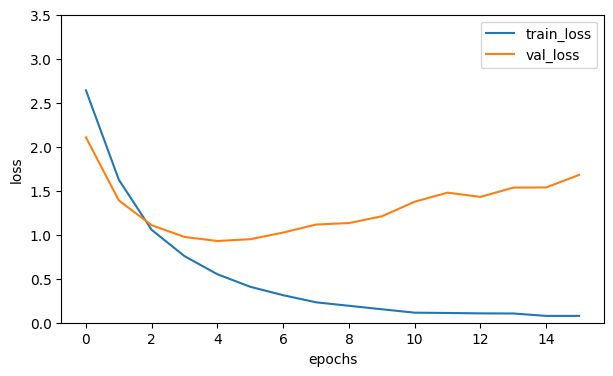

NameError: name 'f1_score' is not defined

In [ ]:
simple_cnn_16 = SimpleCnn(n_classes).to(DEVICE)
history = train(train_dataset, val_dataset, model=simple_cnn_16, epochs=16, batch_size=64)

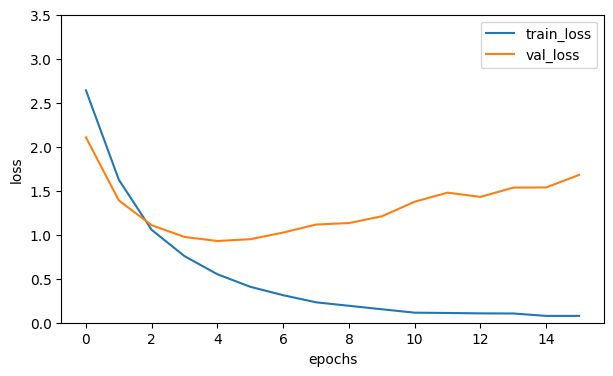

F1: 0.7375


In [41]:
plot_epoch_loss(history)
print(f"F1: {evaluate_f1_score(simple_cnn_16)}")
predict_and_submit(model=simple_cnn_16, submit_name="simple_cnn_16_epochs")

Лучше не становится, только расходиться начинает

# Fine-tuning чего-то посложнее

Умные люди уже придумали архитектуры за нас и пожгли видеокарты чтобы обучить более сложные модели. Попробуем паразитировать на этом, чтобы уложиться в дедлайны домашки.

In [43]:
!pip install timm
import timm


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\efimplotnikov\Projects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Загружаем inception v4

In [ ]:
# Если при обучении падает по out of memory, то память сама не чистится без перезапуска ядра
# так что тут ручная зачистка для повторных запусков
if 'inception_v4' in globals():
    import gc
    del inception_v4
    gc.collect()
    
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

inception_v4 = timm.create_model("inception_v4", pretrained=True)
inception_v4 = inception_v4.to(DEVICE)

Попробуем вариант с подменой последнего линейного слоя и переобучением только его весов.

In [ ]:
num_features = inception_v4.last_linear.in_features
inception_v4.last_linear = nn.Linear(num_features, n_classes).to(DEVICE)

for p in inception_v4.parameters():
    p.requires_grad = False

for p in inception_v4.last_linear.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(inception_v4.last_linear.parameters(), lr=1e-4)

In [ ]:

history_inception_v4 = train(train_dataset, val_dataset, model=inception_v4, epochs=16, batch_size=32, optimizer=optimizer)

epoch:   0%|          | 0/16 [00:00<?, ?it/s]

loss 1.9889611561470437


epoch:   6%|▋         | 1/16 [00:44<11:09, 44.61s/it]


Epoch 001 train_loss: 1.9890     val_loss 1.6990 train_acc 0.4747 val_acc 0.5512
loss 1.3488033323563149


epoch:  12%|█▎        | 2/16 [01:27<10:10, 43.63s/it]

...


Epoch 014 train_loss: 0.4987     val_loss 2.0207 train_acc 0.8542 val_acc 0.5932
loss 0.4945228003974902


epoch:  94%|█████████▍| 15/16 [10:45<00:42, 42.85s/it]


Epoch 015 train_loss: 0.4945     val_loss 1.9612 train_acc 0.8508 val_acc 0.5990
loss 0.4569660299173153


epoch: 100%|██████████| 16/16 [11:28<00:00, 43.01s/it]


Epoch 016 train_loss: 0.4570     val_loss 2.0697 train_acc 0.8630 val_acc 0.5818


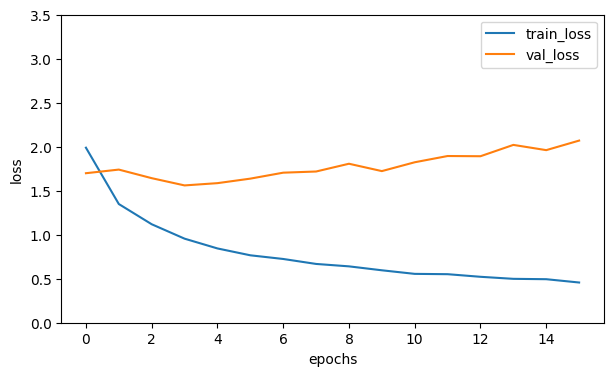

In [ ]:
plot_epoch_loss(history_inception_v4)

In [ ]:
print(f"F1: {evaluate_f1_score(inception_v4)}")

F1: 0.6475


Качество не поражает, хуже чем у примитивной модели.

Надо пробовать более глубокий файн тюнинг.

epoch:   0%|          | 0/16 [00:00<?, ?it/s]

loss 2.1143281379090166


epoch:   6%|▋         | 1/16 [00:45<11:15, 45.01s/it]


Epoch 001 train_loss: 2.1143     val_loss 1.8079 train_acc 0.4477 val_acc 0.5405
loss 1.6042518339245795


epoch:  12%|█▎        | 2/16 [01:29<10:28, 44.88s/it]

...


Epoch 014 train_loss: 0.7263     val_loss 1.5512 train_acc 0.8129 val_acc 0.6204
loss 0.737881809983696


epoch:  94%|█████████▍| 15/16 [10:56<00:43, 43.41s/it]


Epoch 015 train_loss: 0.7379     val_loss 1.5356 train_acc 0.8160 val_acc 0.6146
loss 0.7075477815090497


epoch: 100%|██████████| 16/16 [11:39<00:00, 43.73s/it]


Epoch 016 train_loss: 0.7075     val_loss 1.6307 train_acc 0.8215 val_acc 0.6144


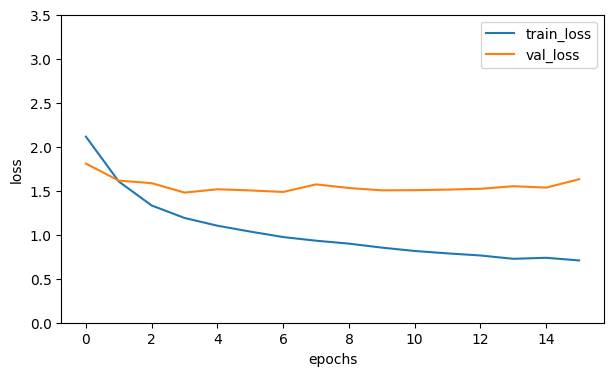

AttributeError: 'list' object has no attribute 'eval'

In [ ]:
inception_v4_fine2 = timm.create_model("inception_v4", pretrained=True)
inception_v4_fine2 = inception_v4_fine2.to(DEVICE)

num_features = inception_v4_fine2.last_linear.in_features
inception_v4_fine2.last_linear = nn.Linear(num_features, n_classes).to(DEVICE)

children = list(inception_v4_fine2.children())
for layer in children:
    for p in layer.parameters():
        p.requires_grad = False
for layer in children[-3:-1]:
    for p in layer.parameters():
        p.requires_grad = True

backbone_params = list(filter(lambda p: p.requires_grad, inception_v4_fine2.parameters()))
head_params = list(inception_v4_fine2.last_linear.parameters())
for p in head_params:
    p.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': inception_v4_fine2.last_linear.parameters(), 'lr': 1e-3},
    {'params': backbone_params, 'lr': 1e-4}
])

history_inception_v4_fine2 = train(train_dataset, val_dataset, 
                             model=inception_v4_fine2, 
                             epochs=16, batch_size=32, 
                             optimizer=optimizer)

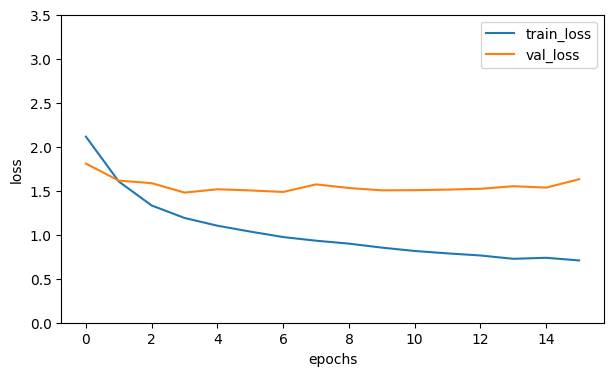

F1: 0.65625


In [50]:
plot_epoch_loss(history_inception_v4_fine2)

print(f"F1: {evaluate_f1_score(inception_v4_fine2)}")

Ничего хорошего не выходит с inception v4. Может, взять что полегковеснее и выиграть на эксериментах с гиперпараметрами?

In [ ]:
nasnet_a_mobile = timm.create_model("NASNet-A-Mobile", pretrained=True)
nasnet_a_mobile = nasnet_a_mobile.to(DEVICE)

num_features = nasnet_a_mobile.last_linear.in_features
nasnet_a_mobile.last_linear = nn.Linear(num_features, n_classes).to(DEVICE)

for p in nasnet_a_mobile.parameters():
    p.requires_grad = False

for p in nasnet_a_mobile.last_linear.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(nasnet_a_mobile.last_linear.parameters(), lr=1e-4)

In [ ]:

history_nasnet_a_mobile = train(train_dataset, val_dataset, model=nasnet_a_mobile, epochs=16, batch_size=32, optimizer=optimizer)

In [ ]:
plot_epoch_loss(history_nasnet_a_mobile)
print(f"F1: {evaluate_f1_score(inception_v4_fine2)}")